### Section 1 — Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

### Section 2 — Load Dataset

In [2]:
df = pd.read_csv("../data/processed/churn_processed.csv")

df.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn,Customer_Engagement,Average_Call_Duration,Revenue_Per_Month
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0,93,60.694444,5.067692
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0,16,53.000000,1.150875
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0,443,40.213115,40.434737
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0,102,62.656716,6.154359
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0,93,40.559322,3.738590


### Section 3 — Dataset Overview

In [3]:
print("Dataset Shape:", df.shape)

print("\nChurn Distribution:")
print(df["Churn"].value_counts())

print("\nChurn Percentage:")
print(df["Churn"].value_counts(normalize=True)*100)

Dataset Shape: (2850, 17)

Churn Distribution:
Churn
0    2404
1     446
Name: count, dtype: int64

Churn Percentage:
Churn
0    84.350877
1    15.649123
Name: proportion, dtype: float64


The dataset contains customer demographic information, service usage, complaints, and subscription details. The target variable is Churn, indicating whether a customer left the telecom service.

### Section 4 — Business Problem 1

C:\Users\Shubham Kumar\AppData\Local\Temp\ipykernel_23832\3422946490.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


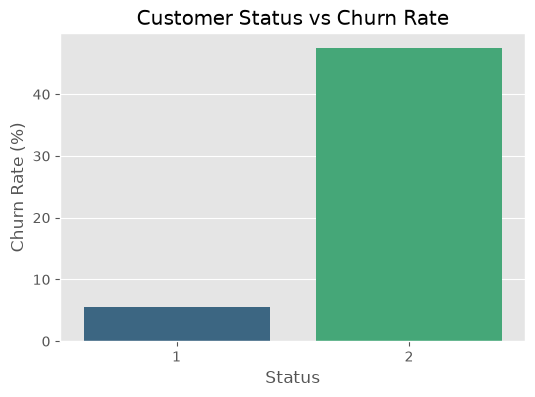

In [4]:
churn_rate = df.groupby("Status")["Churn"].mean()*100

plt.figure(figsize=(6,4))
sns.barplot(
    x=churn_rate.index,
    y=churn_rate.values,
    palette="viridis"
)

plt.title("Customer Status vs Churn Rate")
plt.xlabel("Status")
plt.ylabel("Churn Rate (%)")
plt.show()

Insight

- Customers with Status 2 exhibit a significantly higher churn rate than those with Status 1.

Recommendation

- Develop targeted retention programs for customers categorized under Status 2.

### Section 5 — Business Problem 2

C:\Users\Shubham Kumar\AppData\Local\Temp\ipykernel_23832\316972808.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


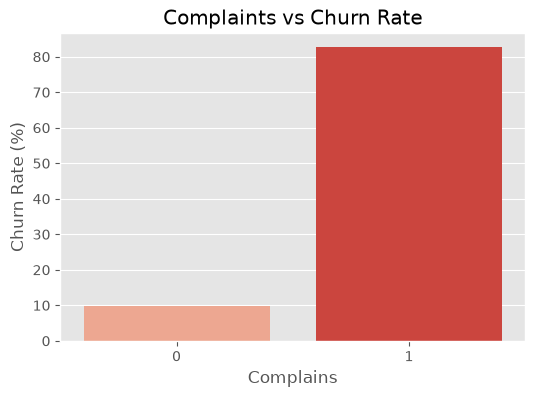

In [5]:
complaints = df.groupby("Complains")["Churn"].mean()*100

plt.figure(figsize=(6,4))
sns.barplot(
    x=complaints.index,
    y=complaints.values,
    palette="Reds"
)

plt.title("Complaints vs Churn Rate")
plt.ylabel("Churn Rate (%)")
plt.show()

Insight

- Customers who register complaints are considerably more likely to churn.

Recommendation

- Reduce complaint resolution time and improve customer support quality.

### Section 6 — Business Problem 3

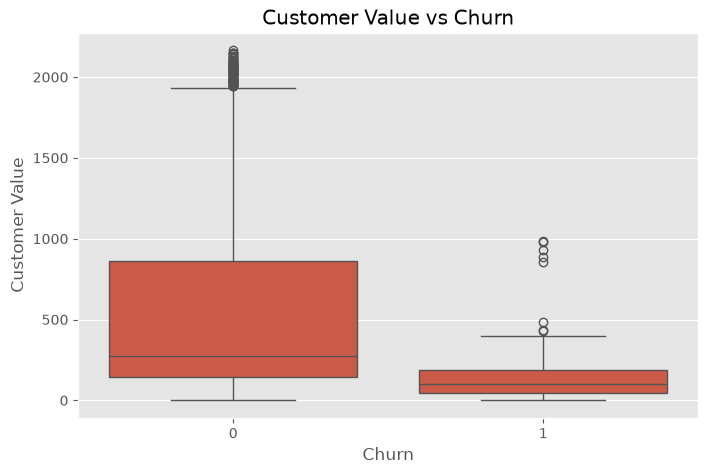

In [ ]:
# Customer Value vs Churn

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="Customer Value",
    data=df
)

plt.title("Customer Value vs Churn")
plt.show()

Insight

- Customers with lower lifetime value tend to churn more frequently.

Recommendation

- Offer personalized loyalty programs and premium benefits to valuable customers.

### Section 7 — Business Problem 4

C:\Users\Shubham Kumar\AppData\Local\Temp\ipykernel_23832\1983662213.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


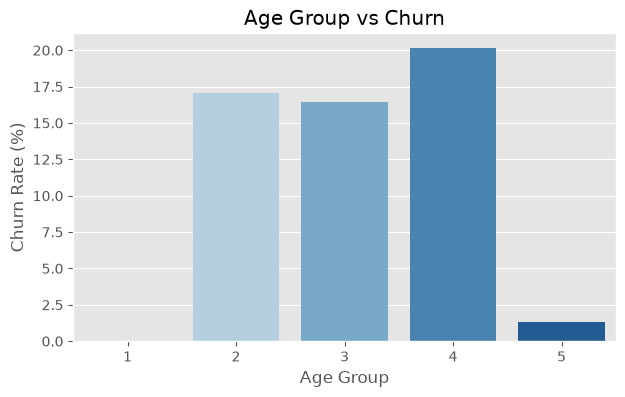

In [7]:
# Age Group Analysis

age = df.groupby("Age Group")["Churn"].mean()*100

plt.figure(figsize=(7,4))

sns.barplot(
    x=age.index,
    y=age.values,
    palette="Blues"
)

plt.title("Age Group vs Churn")
plt.ylabel("Churn Rate (%)")
plt.show()

Insight

- Middle-aged customer groups show relatively higher churn.

Recommendation

- Design customized plans and targeted offers for these age segments.

### Section 8 — Business Problem 5

C:\Users\Shubham Kumar\AppData\Local\Temp\ipykernel_23832\402763391.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


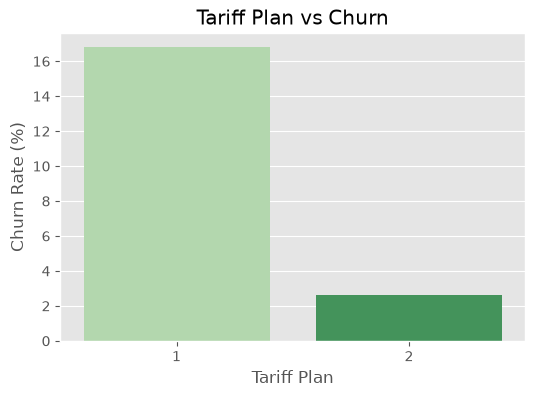

In [8]:
tariff = df.groupby("Tariff Plan")["Churn"].mean()*100

plt.figure(figsize=(6,4))

sns.barplot(
    x=tariff.index,
    y=tariff.values,
    palette="Greens"
)

plt.title("Tariff Plan vs Churn")
plt.ylabel("Churn Rate (%)")
plt.show()

Insight

- Certain tariff plans are associated with higher churn.

Recommendation

- Review pricing and benefits of underperforming tariff plans.

### Section 9 — Business Problem 6

### Service Usage Analysis

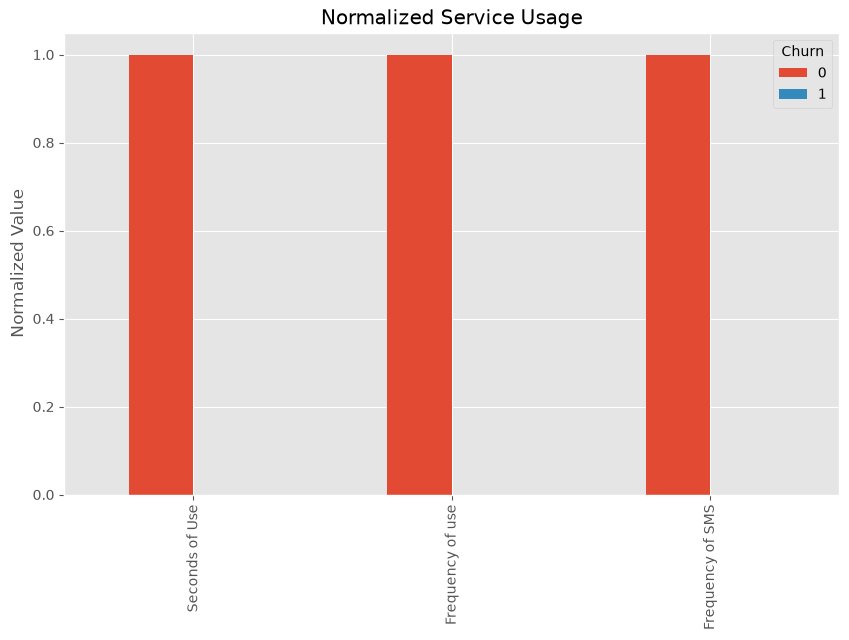

In [13]:
usage = df.groupby("Churn")[[
    "Seconds of Use",
    "Frequency of use",
    "Frequency of SMS"
]].mean()

usage = (usage - usage.min()) / (usage.max() - usage.min())

usage.T.plot(kind="bar", figsize=(10,6))

plt.title("Normalized Service Usage")
plt.ylabel("Normalized Value")
plt.show()

Insight

- Customers with lower service usage are more likely to churn.

Recommendation

- Increase engagement using promotional offers and personalized campaigns.

### Section 10 — Business Problem 7

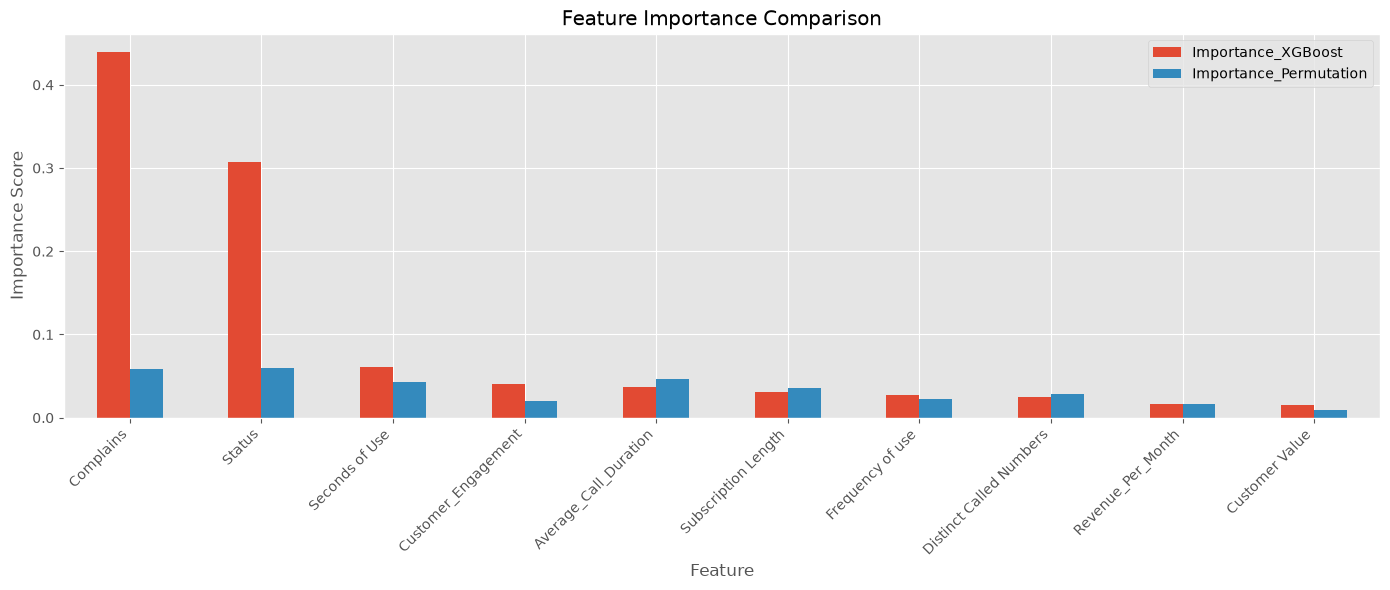

In [14]:
comparison = pd.read_csv("../results/feature_importance.csv")

comparison.set_index("Feature").plot(
    kind="bar",
    figsize=(14,6)
)

plt.title("Feature Importance Comparison")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

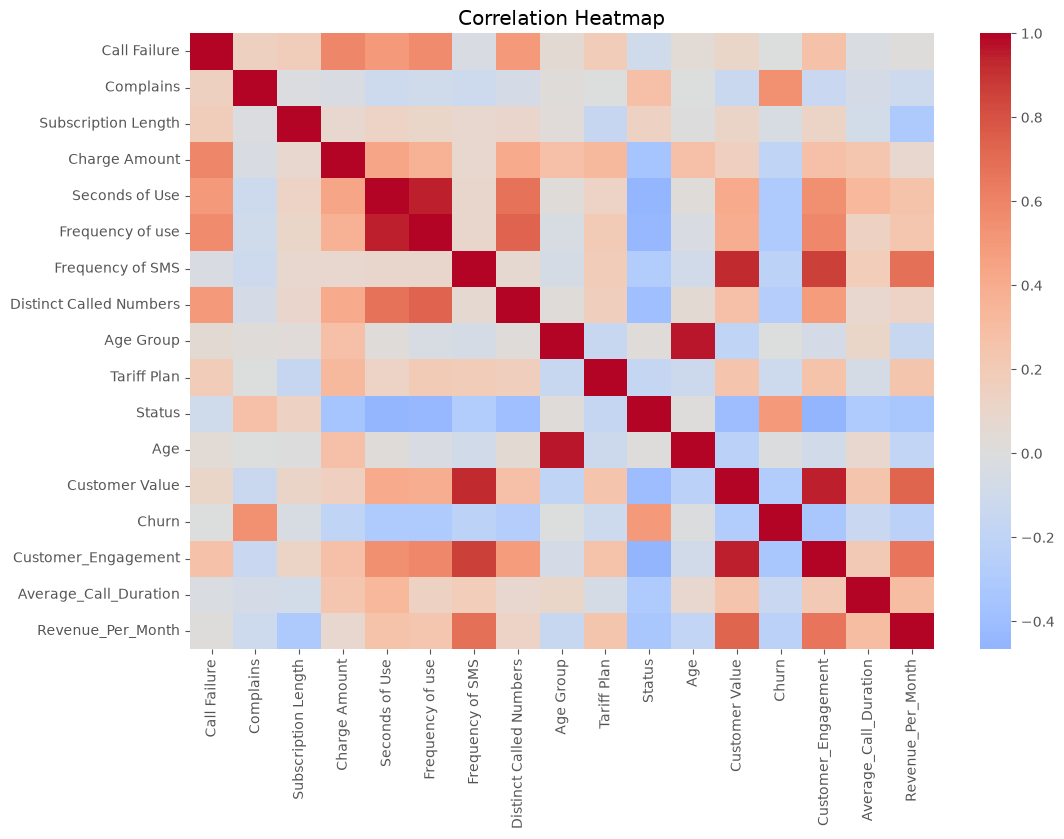

In [15]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

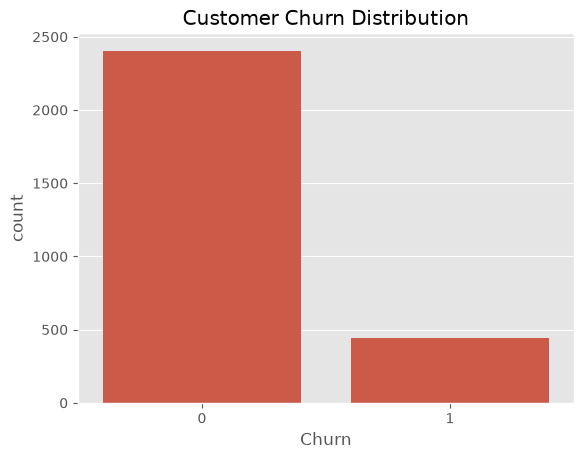

In [16]:
sns.countplot(
    x="Churn",
    data=df
)

plt.title("Customer Churn Distribution")
plt.show()

Business Insights Markdown

- At the end of the notebook, add a markdown section like this:

Key Business Insights
- Customers with complaints have the highest churn rate (>80%).
- Status is one of the strongest predictors of churn.
- Customers on Tariff Plan 1 are significantly more likely to churn.
- Customers with low Customer Value are more likely to leave.
- Middle-aged customers (Age Group 4) exhibit the highest churn.
- Churned customers show reduced service usage compared to retained customers.
- Feature importance analysis confirms Complaints, Status, and Usage metrics as the strongest predictors.
- These insights can be used to build proactive retention strategies targeting high-risk customers.